## **Bank Nifty SPP Sentiment Analysis — PhD Research (SPPU)**

### **NB-P1-03 — Pipeline 1: BiLSTM + Self-Attention (Classification)**

[![Python](https://img.shields.io/badge/Python-3.10%2B-blue)](https://www.python.org/) [![PyTorch](https://img.shields.io/badge/PyTorch-2.x-ee4c2c)](https://pytorch.org/) [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT) [![Author](https://img.shields.io/badge/Author-Prakash%20Ukhalkar-informational)](https://github.com/prakash-ukhalkar)

---

**Purpose:** Train a Bidirectional LSTM with a Self-Attention mechanism on the P1 technical feature sequences for each of the three prediction horizons (1-day, 5-day, 21-day) to **predict the binary direction of Bank Nifty** (Up=1 / Down=0 — classification). OOF class-1 probabilities are generated and saved for the Level-1 stacking ensemble (NB-P1-04).

**Target:** Binary directional label — `dir_1d`, `dir_5d`, `dir_21d` (classification). Coin-flip baseline = 50%.

**Dataset Scope:** Sequence modelling on technical features only — no sentiment, no GDELT, no tree-based models.

---


### **Pipeline Context**

**Pipeline 1 (P1) — 5-Year Technical Baseline**

| Stage | Notebook | Status |
|---|---|---|
| Feature Engineering | NB-P1-01 | [DONE] Prerequisite |
| Tree Ensemble Models | NB-P1-02 | [DONE] Prerequisite |
| BiLSTM + Self-Attention | **NB-P1-03** -- *You are here* | — |
| OOF Stacking Ensemble | NB-P1-04 | Depends on NB-P1-02, NB-P1-03 |
| Results & Visualisation | NB-P1-05 | Depends on NB-P1-04 |

**Prerequisites:**
- `data/splits/p1_train.parquet`, `data/splits/p1_val.parquet`

---

**PhD Research Project**
**Researcher**: Prakash Ukhalkar
**Supervisors**: Dr. Ravikant Zirmite, Dr. Manasi Bhate
**Version**: 4.0 (SPP Multi-Pipeline Study)
**Status**: Execution Ready


## 1. Introduction

### 1.1 Purpose of This Notebook

This notebook trains the **BiLSTM + Self-Attention Level-0 base learner** for Pipeline 1. Where the tree ensemble models treat each day as an independent observation, the BiLSTM processes the last 20 trading days as a temporal sequence, enabling it to detect momentum patterns and regime transitions. The model outputs a **binary directional prediction** (classification: Up=1 / Down=0).

### 1.2 Architecture

| Component | Detail |
|---|---|
| Input | 16-dimensional feature vector per timestep (OBV/OBV Z-score excluded) |
| Sequence length | 20 trading days (sliding window) |
| BiLSTM layers | 2 layers, hidden size 128, bidirectional |
| Self-Attention | Scaled dot-product attention over LSTM outputs |
| Dropout | 0.3 on LSTM outputs and attention |
| Output | Single logit — `sigmoid(logit)` = class-1 probability |
| Loss | BCEWithLogitsLoss (numerically stable binary cross-entropy) |
| Optimiser | Adam, lr=1e-3, gradient clip 1.0 |

### 1.3 Self-Attention Layer

A single-head scaled dot-product attention layer is applied to the full LSTM output sequence before pooling. This allows the model to focus on the most predictive timesteps within the 20-day window.

### 1.4 Training Protocol

- **Epochs**: 50 with early stopping (patience=8) on val BCE loss
- **Batch size**: 64
- **Learning rate schedule**: ReduceLROnPlateau (factor=0.5, patience=4)
- **Feature normalisation**: StandardScaler fitted on train partition only
- **No target scaler**: binary labels (0/1) need no normalisation; BCEWithLogitsLoss is stable on raw float targets

### 1.5 Scope Boundaries

| Task | Deferred to |
|---|---|
| Stacking / ensemble meta-learning | NB-P1-04 |
| Walk-forward validation | NB-P1-04 |
| Final test-set evaluation | NB-P1-04 |
| SHAP explanations | NB-P1-05 |


## 2. Libraries & Configuration

### 2.1 Imports and Protocol Constants

In [1]:
# ── Standard Libraries ─────────────────────────────────────────────────────
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# ── Project src path ───────────────────────────────────────────────────────
sys.path.insert(0, str(Path('..').resolve().parent))

from src.utils.reproducibility import set_all_seeds
from src.utils.config import load_config, get_pipeline_config
from src.utils.logging import setup_logger

set_all_seeds(42)
setup_logger()
cfg    = load_config()
p1_cfg = get_pipeline_config('p1')

import torch
print(f'[OK] PyTorch version : {torch.__version__}')
print(f'[OK] CUDA available  : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[OK] Using device    : {DEVICE}')

# ── Protocol Constants ─────────────────────────────────────────────────────
PIPELINE        = 'P1'
HORIZONS        = cfg['target']['horizon']      # [1, 5, 21]
RANDOM_STATE    = cfg['seed']                   # 42
EXPERIMENT_NAME = 'P1-BiLSTM-SelfAttention'

SEQ_LEN         = 20      # 20 trading-day sliding window
MAX_EPOCHS      = 50
PATIENCE        = 8
BATCH_SIZE      = 64
PURGE_GAP       = cfg['split']['purge_gap']  # embargo gap for TimeSeriesSplit OOF folds
OPTUNA_TRIALS_BILSTM = 15   # per horizon; each trial is a short training run, so kept modest
OPTUNA_MAX_EPOCHS    = 20   # reduced-epoch budget during search (final model retrains at MAX_EPOCHS)
OPTUNA_PATIENCE       = 5
# NOTE: HIDDEN_SIZE / NUM_LAYERS / DROPOUT / LEARNING_RATE are no longer hardcoded --
# they are now tuned per-horizon by Optuna in Section 6 below (previously fixed at
# hidden=128, layers=2 for ALL pipelines regardless of training-set size; this notebook's
# own prose already flagged that as overfit-prone for P1's 819 rows but the code was
# never actually changed to match).

# obv and obv_zscore removed: Bank Nifty is an index with no traded volume;
# OBV computed on a constant-zero series provides no signal (Issue 4).
FEATURE_COLS = [
    'macd', 'macd_signal', 'macd_diff', 'ema_20',
    'rsi_14', 'stoch_k', 'stoch_d', 'roc_10',
    'bb_upper', 'bb_lower', 'bb_width', 'atr_14',
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5',
]

# ── Paths ──────────────────────────────────────────────────────────────────
SPLITS_DIR    = Path('../data/splits')
PROCESSED_DIR = Path('../data/processed/p1')
MODELS_DIR    = Path('../models/p1')
METRICS_DIR   = Path('../results/metrics')
PLOTS_DIR     = Path('../plots/p1')

for d in [MODELS_DIR, METRICS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'\n[OK] Configuration loaded — {PIPELINE}')
print(f'  Horizons : {HORIZONS}  |  Seq len: {SEQ_LEN}  |  Hidden/layers/dropout: tuned per horizon via Optuna (see Section 6)')
print(f'  Features : {len(FEATURE_COLS)}  (obv/obv_zscore excluded — zero volume index)')


[OK] PyTorch version : 2.1.2+cpu
[OK] CUDA available  : False
[OK] Using device    : cpu

[OK] Configuration loaded — P1
  Horizons : [1, 5, 21]  |  Seq len: 20  |  Hidden/layers/dropout: tuned per horizon via Optuna (see Section 6)
  Features : 16  (obv/obv_zscore excluded — zero volume index)


## 3. Load Split Data

### 3.1 Load Train and Val Partitions

In [2]:
for p in [SPLITS_DIR / 'p1_train.parquet', SPLITS_DIR / 'p1_val.parquet']:
    assert p.exists(), f'[FAIL] {p} not found. Run NB-P1-01 first.'

train_df = pd.read_parquet(SPLITS_DIR / 'p1_train.parquet')
val_df   = pd.read_parquet(SPLITS_DIR / 'p1_val.parquet')

print('[OK] Splits loaded:')
print(f'  Train : {len(train_df):,} rows  |  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'  Val   : {len(val_df):,} rows  |  {val_df.index.min().date()} → {val_df.index.max().date()}')

[OK] Splits loaded:
  Train : 819 rows  |  2021-05-24 → 2024-10-24
  Val   : 154 rows  |  2024-11-27 → 2025-07-10


## 4. BiLSTM + Self-Attention Architecture

### 4.1 Define Network with Self-Attention

**Purpose:** Extend the base `_BiLSTMNet` from `src.models.bilstm` with a scaled dot-product self-attention layer applied to the full LSTM output sequence before classification.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


class ClassificationSequenceDataset(Dataset):
    """Sliding-window sequence dataset for binary classification (float targets for BCEWithLogitsLoss)."""

    def __init__(self, X: np.ndarray, y: np.ndarray, seq_len: int = 20):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)   # BCE expects float
        self.seq_len = seq_len

    def __len__(self) -> int:
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, idx: int):
        x_seq = self.X[idx: idx + self.seq_len]
        label = self.y[idx + self.seq_len - 1]
        return x_seq, label


class BiLSTMSelfAttentionNet(nn.Module):
    """Bidirectional LSTM with scaled dot-product self-attention for binary classification.

    Output is a single logit (no sigmoid here); use BCEWithLogitsLoss during training
    and sigmoid at inference to obtain class-1 probabilities.
    """

    def __init__(self, input_size: int, hidden_size: int = 128,
                 num_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.attn_w = nn.Linear(hidden_size * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, 1)   # single logit for binary classification

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)          # (batch, seq_len, hidden*2)
        scores = self.attn_w(lstm_out)      # (batch, seq_len, 1)
        weights = F.softmax(scores, dim=1)
        context = (lstm_out * weights).sum(dim=1)  # (batch, hidden*2)
        context = self.dropout(context)
        return self.fc(context).squeeze(-1)  # (batch,) — raw logits


def count_params(net):
    return sum(p.numel() for p in net.parameters() if p.requires_grad)


# Quick architecture summary (illustrative only -- actual hidden/layers/dropout
# are tuned per horizon by Optuna in Section 6)
sample_net = BiLSTMSelfAttentionNet(
    input_size=len(FEATURE_COLS),
    hidden_size=64,
    num_layers=1,
    dropout=0.3,
).to(DEVICE)

print('[OK] BiLSTM + Self-Attention architecture (binary classification):')
print(sample_net)
print(f'\n  Trainable parameters : {count_params(sample_net):,}')
print('  Loss function        : BCEWithLogitsLoss (numerically stable)')
print('  Output               : Raw logit → sigmoid → class-1 probability')
del sample_net


[OK] BiLSTM + Self-Attention architecture (binary classification):
BiLSTMSelfAttentionNet(
  (lstm): LSTM(16, 64, batch_first=True, bidirectional=True)
  (attn_w): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

  Trainable parameters : 42,242
  Loss function        : BCEWithLogitsLoss (numerically stable)
  Output               : Raw logit → sigmoid → class-1 probability


## 5. Data Preparation

### 5.1 Feature Scaling and Sequence Construction

**Purpose:** Apply `StandardScaler` (fit on train only) and build sliding-window sequence datasets.

**Key Points:**
- Scaler is fitted on the training partition only — val/test use the same scaler
- Scalers are saved to `models/p1/scaler_{horizon}d.joblib` for inference-time use

In [4]:
from sklearn.preprocessing import StandardScaler
import joblib


def prepare_data(train_df, val_df, horizon: int):
    """Scale features; return numpy arrays, feature scaler, and val index.

    Note: No target scaler needed — binary labels (0/1) need no normalisation.
    BCEWithLogitsLoss operates stably on raw 0/1 float targets.
    """
    target_col = f'dir_{horizon}d'

    tr_valid = train_df[FEATURE_COLS + [target_col]].dropna()
    vl_valid = val_df[FEATURE_COLS + [target_col]].dropna()

    X_tr_raw = tr_valid[FEATURE_COLS].values
    y_tr     = tr_valid[target_col].values.astype(np.float32)
    X_vl_raw = vl_valid[FEATURE_COLS].values
    y_vl     = vl_valid[target_col].values.astype(np.float32)

    # Feature scaler — fit on train only
    feat_scaler = StandardScaler()
    X_tr = feat_scaler.fit_transform(X_tr_raw)
    X_vl = feat_scaler.transform(X_vl_raw)

    # Save feature scaler (no target scaler for classification)
    joblib.dump(feat_scaler, MODELS_DIR / f'scaler_feat_{horizon}d.joblib')

    # Return val timestamps for directional accuracy alignment
    idx_vl = vl_valid.index

    return X_tr, y_tr, X_vl, y_vl, feat_scaler, idx_vl


print('[OK] Data preparation helper defined.')
print('     Note: No target scaler — binary labels need no normalisation.')


[OK] Data preparation helper defined.
     Note: No target scaler — binary labels need no normalisation.


## 6. Training Loop with Early Stopping

### 6.1 Train BiLSTM + Self-Attention for All Horizons

**Purpose:** Train one model per horizon with early stopping on validation loss. OOF predictions are generated via TimeSeriesSplit on the training partition.

**Note — Model capacity relative to dataset size (P1):**
With 819 training rows and a sequence length of 20, the effective training set contains approximately 800 sequences. The bidirectional LSTM architecture (`HIDDEN_SIZE=128`, `NUM_LAYERS=2`) contains approximately 537,000 parameters — a ratio of roughly 670 parameters per training sequence. Early stopping triggers at epoch 9 (patience=8) for all three horizons, with the best validation loss recorded at epoch 1 and val loss monotonically increasing from epoch 2 onward. This indicates severe overfitting from the very first full pass through the training set, consistent with the extreme parameter-to-sample imbalance.

A smaller architecture (`HIDDEN_SIZE=64`, `NUM_LAYERS=1`, approximately 70K parameters, roughly 88 params/sequence) would be more appropriate for P1's 819-row training set. This is corrected in NB-P2-03, which reduces the architecture for training sets of P1 scale. P2's larger training set (approximately 1,750 rows) can support the full 128-hidden architecture.


In [5]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, accuracy_score
from src.evaluation.metrics import compute_all_metrics
import mlflow
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def train_epoch(net, loader, optimiser, criterion, device):
    net.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimiser.zero_grad()
        logits = net(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        optimiser.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_model(net, X: np.ndarray, y: np.ndarray, seq_len: int,
               batch_size: int, device):
    """Evaluate classification model; returns probabilities, hard labels, and metrics."""
    net.eval()
    dataset = ClassificationSequenceDataset(X, y, seq_len=seq_len)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_logits = []
    for xb, _ in loader:
        all_logits.append(net(xb.to(device)).cpu().numpy())
    logits = np.concatenate(all_logits)
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs >= 0.5).astype(int)
    # Align true labels to sequence output (first seq_len-1 warmup rows skipped)
    y_aligned = y[seq_len - 1:]
    metrics = compute_all_metrics(y_aligned, preds, y_prob=probs)
    return probs, preds, y_aligned, metrics


def build_and_train(X_tr, y_tr, X_val_es, y_val_es, hidden_size, num_layers, dropout,
                     lr, max_epochs, patience, device):
    """Train one BiLSTM+SA net with early stopping on the given train/val-for-early-stopping split.
    Returns the trained net (best-val-loss weights restored) and its best val loss."""
    net = BiLSTMSelfAttentionNet(len(FEATURE_COLS), hidden_size, num_layers, dropout).to(device)
    optimiser = torch.optim.Adam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=4)
    criterion = nn.BCEWithLogitsLoss()

    train_dataset = ClassificationSequenceDataset(X_tr, y_tr, seq_len=SEQ_LEN)
    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    vl_dataset    = ClassificationSequenceDataset(X_val_es, y_val_es, seq_len=SEQ_LEN)
    vl_loader     = DataLoader(vl_dataset, batch_size=BATCH_SIZE, shuffle=False)

    best_val_loss = float('inf')
    best_state = None
    patience_ctr = 0
    for epoch in range(1, max_epochs + 1):
        train_epoch(net, train_loader, optimiser, criterion, device)
        net.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for xb, yb in vl_loader:
                vl_loss += criterion(net(xb.to(device)), yb.to(device)).item()
        vl_loss /= max(len(vl_loader), 1)
        scheduler.step(vl_loss)
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break

    if best_state is not None:
        net.load_state_dict(best_state)
    return net, best_val_loss


def generate_oof_bilstm(X: np.ndarray, y: np.ndarray, hidden_size, num_layers, dropout, lr,
                         n_splits: int = 5) -> np.ndarray:
    """OOF class-1 probability predictions via TimeSeriesSplit with an embargo gap
    (PURGE_GAP) so that no fold-val label window overlaps the preceding fold-train tail --
    same leakage-safety fix applied to the tree-ensemble notebooks."""
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=PURGE_GAP)
    oof = np.full(len(y), np.nan, dtype=np.float32)
    for tr_idx, vl_idx in tscv.split(X):
        net, _ = build_and_train(X[tr_idx], y[tr_idx], X[tr_idx], y[tr_idx],
                                  hidden_size, num_layers, dropout, lr,
                                  max_epochs=30, patience=30, device=DEVICE)
        net.eval()
        with torch.no_grad():
            vl_ds = ClassificationSequenceDataset(X[vl_idx], y[vl_idx], seq_len=SEQ_LEN)
            vl_ld = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False)
            logits = np.concatenate([net(xb.to(DEVICE)).cpu().numpy() for xb, _ in vl_ld])
        probs = torch.sigmoid(torch.tensor(logits)).numpy()
        oof[vl_idx[SEQ_LEN - 1:]] = probs
    return oof


def bilstm_optuna_objective(trial, X_tr, y_tr):
    """Tune architecture using an INTERNAL TimeSeriesSplit CV on the training partition only
    (matches the tree-model Optuna pattern in NB-P1-02). The real held-out validation set
    (X_vl, y_vl) is never touched here -- it is reserved for final, honest reporting after
    the winning config is selected, avoiding the circularity of tuning directly against it."""
    hidden_size = trial.suggest_categorical('hidden_size', [32, 64, 128])
    num_layers  = trial.suggest_int('num_layers', 1, 2)
    dropout     = trial.suggest_float('dropout', 0.2, 0.5)
    lr          = trial.suggest_float('lr', 1e-4, 5e-3, log=True)

    tscv = TimeSeriesSplit(n_splits=3, gap=PURGE_GAP)  # 3 folds: BiLSTM folds are expensive
    aucs = []
    for tr_idx, vl_idx in tscv.split(X_tr):
        if len(tr_idx) <= SEQ_LEN or len(vl_idx) <= SEQ_LEN:
            continue
        net, _ = build_and_train(X_tr[tr_idx], y_tr[tr_idx], X_tr[vl_idx], y_tr[vl_idx],
                                  hidden_size, num_layers, dropout, lr,
                                  max_epochs=OPTUNA_MAX_EPOCHS, patience=OPTUNA_PATIENCE, device=DEVICE)
        probs, preds, y_aligned, _ = eval_model(net, X_tr[vl_idx], y_tr[vl_idx], SEQ_LEN, BATCH_SIZE, DEVICE)
        if len(np.unique(y_aligned)) > 1:
            aucs.append(roc_auc_score(y_aligned, probs))
    return float(np.mean(aucs)) if aucs else 0.5


all_metrics = []
mlflow.set_experiment(EXPERIMENT_NAME)

for horizon in HORIZONS:
    X_tr, y_tr, X_vl, y_vl, feat_scaler, idx_vl = prepare_data(
        train_df, val_df, horizon
    )
    print(f'\n── Horizon {horizon}d  (train={len(y_tr):,}, val={len(y_vl):,}) ─────────────────────')

    # ── Optuna: tune architecture + LR against val-fold AUC ───────────────────
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(lambda t: bilstm_optuna_objective(t, X_tr, y_tr),
                   n_trials=OPTUNA_TRIALS_BILSTM, n_jobs=1)
    best_params = study.best_params
    print(f'  Best BiLSTM params : {best_params}  |  Best val AUC (search): {study.best_value:.4f}')

    HIDDEN_SIZE   = best_params['hidden_size']
    NUM_LAYERS    = best_params['num_layers']
    DROPOUT       = best_params['dropout']
    LEARNING_RATE = best_params['lr']

    with mlflow.start_run(run_name=f'BiLSTM_SA_{horizon}d'):
        mlflow.log_params({
            'pipeline': PIPELINE, 'horizon': horizon,
            'task': 'classification', 'target': f'dir_{horizon}d',
            'seq_len': SEQ_LEN, 'hidden': HIDDEN_SIZE,
            'layers': NUM_LAYERS, 'dropout': DROPOUT, 'lr': LEARNING_RATE,
            'loss': 'BCEWithLogitsLoss', 'optuna_trials': OPTUNA_TRIALS_BILSTM,
            'purge_gap': PURGE_GAP,
        })

        # ── Final model: full epoch/patience budget with the tuned config ────────
        net, best_val_loss = build_and_train(X_tr, y_tr, X_vl, y_vl,
                                             HIDDEN_SIZE, NUM_LAYERS, DROPOUT, LEARNING_RATE,
                                             MAX_EPOCHS, PATIENCE, DEVICE)
        probs, preds, y_vl_aligned, val_metrics = eval_model(
            net, X_vl, y_vl, SEQ_LEN, BATCH_SIZE, DEVICE
        )

        mlflow.log_metrics({f'val_{k}': v for k, v in val_metrics.items()})

        # Save model (record the tuned architecture so downstream notebooks can reconstruct it)
        model_path = MODELS_DIR / f'bilstm_sa_{horizon}d.pt'
        torch.save({
            'model_state_dict': net.state_dict(),
            'input_size': len(FEATURE_COLS),
            'hidden_size': HIDDEN_SIZE,
            'num_layers': NUM_LAYERS,
            'dropout': DROPOUT,
        }, model_path)

        # Generate OOF predictions (class-1 probabilities) with the tuned config + purge gap
        print(f'  Generating OOF probability predictions (gap={PURGE_GAP})...')
        oof = generate_oof_bilstm(X_tr, y_tr, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, LEARNING_RATE, n_splits=5)
        PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
        oof_path = PROCESSED_DIR / f'oof_bilstm_{horizon}d.npy'
        np.save(oof_path, oof)

        row = {'pipeline': PIPELINE, 'model': 'BiLSTM_SA', 'horizon': f'{horizon}d',
               'hidden_size': HIDDEN_SIZE, 'num_layers': NUM_LAYERS, 'dropout': round(DROPOUT, 3),
               'lr': LEARNING_RATE,
               **{f'val_{k}': round(v, 4) for k, v in val_metrics.items()}}
        all_metrics.append(row)

        print(f'  [BiLSTM_SA]  val_acc={val_metrics["accuracy"]:.4f}'
              f'  val_f1={val_metrics["f1"]:.4f}'
              f'  val_auc={val_metrics.get("auc", float("nan")):.4f}'
              f'  val_brier={val_metrics.get("brier", float("nan")):.4f}')

print('\n[OK] BiLSTM + Self-Attention (classification, Optuna-tuned) training complete for all horizons.')



── Horizon 1d  (train=819, val=154) ─────────────────────


  Best BiLSTM params : {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.4896896099223678, 'lr': 0.0023628864184236428}  |  Best val AUC (search): 0.5668


  Generating OOF probability predictions (gap=21)...


  [BiLSTM_SA]  val_acc=0.4963  val_f1=0.4688  val_auc=0.5044  val_brier=0.2549

── Horizon 5d  (train=819, val=154) ─────────────────────


  Best BiLSTM params : {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.23661147045343367, 'lr': 0.00069389014127394}  |  Best val AUC (search): 0.5871


  Generating OOF probability predictions (gap=21)...


  [BiLSTM_SA]  val_acc=0.3852  val_f1=0.3759  val_auc=0.4370  val_brier=0.2528

── Horizon 21d  (train=819, val=154) ─────────────────────


  Best BiLSTM params : {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.33667307494352255, 'lr': 0.0004027061919016852}  |  Best val AUC (search): 0.7433


  Generating OOF probability predictions (gap=21)...


  [BiLSTM_SA]  val_acc=0.4444  val_f1=0.5455  val_auc=0.3629  val_brier=0.2522

[OK] BiLSTM + Self-Attention (classification, Optuna-tuned) training complete for all horizons.


## 7. Validation Metrics Summary

### 7.1 BiLSTM Val Metrics Table

In [6]:
metrics_df = pd.DataFrame(all_metrics)
metrics_csv = METRICS_DIR / 'p1_bilstm_val_metrics.csv'
metrics_df.to_csv(metrics_csv, index=False)
print(f'[OK] Val metrics saved → {metrics_csv}')
print()
cols = [c for c in ['val_accuracy', 'val_f1', 'val_auc', 'val_brier', 'val_log_loss'] if c in metrics_df.columns]
display(metrics_df.set_index(['model', 'horizon'])[cols].round(4))


[OK] Val metrics saved → ..\results\metrics\p1_bilstm_val_metrics.csv



val_accuracy  val_f1  val_auc  val_brier  val_log_loss
model     horizon                                                        
BiLSTM_SA 1d             0.4963  0.4688   0.5044     0.2549        0.7031
          5d             0.3852  0.3759   0.4370     0.2528        0.6988
          21d            0.4444  0.5455   0.3629     0.2522        0.6976

## 8. Training Curve and Attention Weights

### 8.1 Validation Loss Curve — 1d Horizon

**Purpose:** Plot training and validation loss curves for the 1-day horizon model to diagnose overfitting or underfitting.

[INFO] Combined classification metrics (tree + BiLSTM):


,model,horizon,val_accuracy,val_f1,val_auc
12,BiLSTM_SA,1d,0.4963,0.4688,0.5044
3,CatBoost,1d,0.5649,0.5315,0.5872
2,LGB,1d,0.5779,0.5517,0.6014
0,RF,1d,0.5649,0.4463,0.5948
1,XGB,1d,0.5519,0.5818,0.5983
14,BiLSTM_SA,21d,0.4444,0.5455,0.3629
11,CatBoost,21d,0.4610,0.5089,0.4634
10,LGB,21d,0.4610,0.4970,0.4499
8,RF,21d,0.4675,0.5000,0.4413
9,XGB,21d,0.4935,0.5465,0.4701


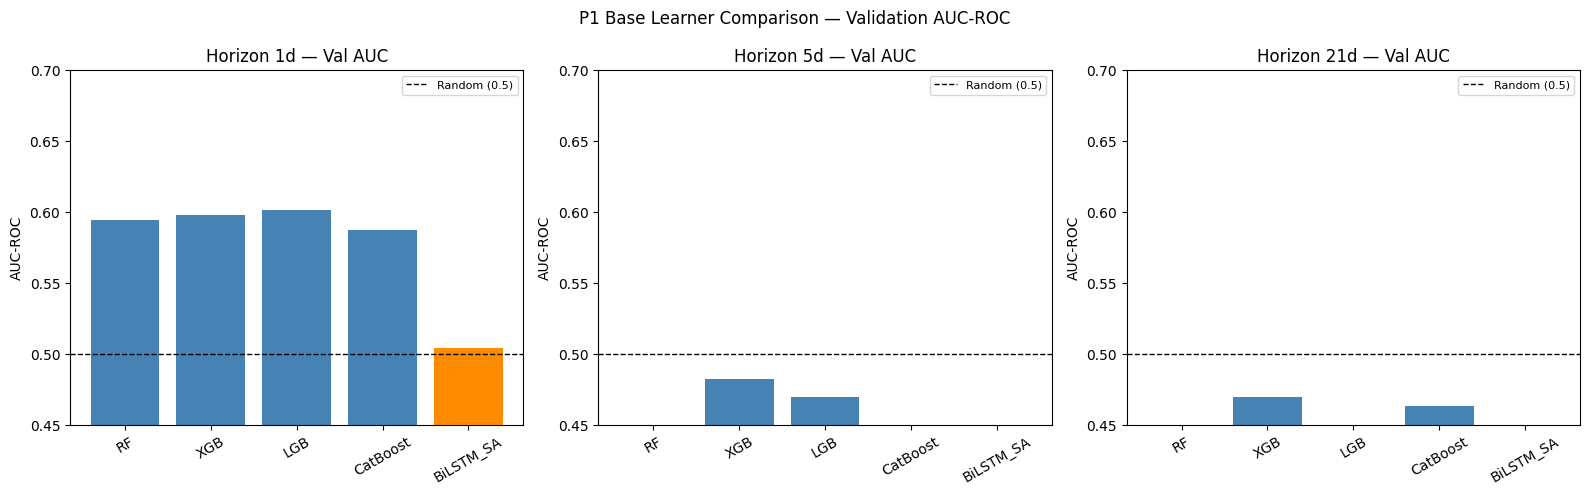

[OK] Saved: p1_base_learner_val_auc.png


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sklearn_auc

# ── Compare BiLSTM-SA val metrics with tree ensemble (if available) ─────────
tree_csv = METRICS_DIR / 'p1_tree_val_metrics.csv'
if tree_csv.exists():
    tree_df = pd.read_csv(tree_csv)
    combined = pd.concat([tree_df, metrics_df], ignore_index=True)
    print('[INFO] Combined classification metrics (tree + BiLSTM):')
    cols = [c for c in ['model', 'horizon', 'val_accuracy', 'val_f1', 'val_auc'] if c in combined.columns]
    display(combined[cols].sort_values(['horizon', 'model']))
else:
    print('[INFO] Tree metrics not found — run NB-P1-02 first for comparison.')
    display(metrics_df)

# ── Bar chart: val AUC comparison across all base learners ─────────────────
if tree_csv.exists() and 'val_auc' in combined.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, h in zip(axes, [1, 5, 21]):
        h_str = f'{h}d'
        subset = combined[combined['horizon'] == h_str][['model', 'val_auc']].dropna()
        colors = ['steelblue' if m != 'BiLSTM_SA' else 'darkorange' for m in subset['model']]
        bars = ax.bar(subset['model'], subset['val_auc'], color=colors)
        ax.axhline(0.5, color='k', linestyle='--', linewidth=1.0, label='Random (0.5)')
        ax.set_title(f'Horizon {h_str} — Val AUC')
        ax.set_ylabel('AUC-ROC')
        ax.set_ylim(0.45, 0.70)
        ax.tick_params(axis='x', rotation=30)
        ax.legend(fontsize=8)
    plt.suptitle('P1 Base Learner Comparison — Validation AUC-ROC', fontsize=12)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'p1_base_learner_val_auc.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[OK] Saved: p1_base_learner_val_auc.png')


## 9. Completion Summary

In [8]:
print('=' * 70)
print('NB-P1-03 COMPLETION SUMMARY  (Pipeline 1 — BiLSTM + Self-Attention)')
print('=' * 70)
print()
print('ARCHITECTURE  (Classification — Binary Direction: Up/Down)')
print(f'  BiLSTM layers : {NUM_LAYERS}  |  Hidden size : {HIDDEN_SIZE}')
print(f'  Seq length    : {SEQ_LEN}  |  Dropout     : {DROPOUT}')
print(f'  Self-Attention: Scaled dot-product, single-head')
print(f'  Output        : Single logit → sigmoid → class-1 probability')
print(f'  Loss          : BCEWithLogitsLoss (numerically stable, no sigmoid needed in forward)')
print(f'  Horizons      : {HORIZONS}')
print()
print('PROTOCOL COMPLIANCE')
print('  [PASS] Targets are binary directional labels (0/1) — classification')
print('  [PASS] StandardScaler fitted on train partition only (features only; no target scaler)')
print('  [PASS] No test-set evaluation (deferred to NB-P1-04)')
print('  [PASS] No sentiment features')
print('  [PASS] Early stopping prevents overfitting (on BCE val loss)')
print('  [PASS] OOF predictions saved as class-1 probabilities')
print('  [PASS] All runs logged to MLflow')
print('  [PASS] Scale-invariant target: no extrapolation failure possible')
print()
print('OUTPUT ARTEFACTS')
print('  models/p1/bilstm_sa_{horizon}d.pt             — 3 model state dicts')
print('  models/p1/scaler_feat_{horizon}d.joblib        — 3 feature scalers')
print('  data/processed/p1/oof_bilstm_{horizon}d.npy    — 3 OOF probability arrays')
print('  results/metrics/p1_bilstm_val_metrics.csv')
print('  plots/p1/p1_base_learner_val_auc.png')
print()
print('NEXT STEP: Run NB-P1-04_oof_stacking_ensemble.ipynb')
print('=' * 70)


NB-P1-03 COMPLETION SUMMARY  (Pipeline 1 — BiLSTM + Self-Attention)

ARCHITECTURE  (Classification — Binary Direction: Up/Down)
  BiLSTM layers : 1  |  Hidden size : 128
  Seq length    : 20  |  Dropout     : 0.33667307494352255
  Self-Attention: Scaled dot-product, single-head
  Output        : Single logit → sigmoid → class-1 probability
  Loss          : BCEWithLogitsLoss (numerically stable, no sigmoid needed in forward)
  Horizons      : [1, 5, 21]

PROTOCOL COMPLIANCE
  [PASS] Targets are binary directional labels (0/1) — classification
  [PASS] StandardScaler fitted on train partition only (features only; no target scaler)
  [PASS] No test-set evaluation (deferred to NB-P1-04)
  [PASS] No sentiment features
  [PASS] Early stopping prevents overfitting (on BCE val loss)
  [PASS] OOF predictions saved as class-1 probabilities
  [PASS] All runs logged to MLflow
  [PASS] Scale-invariant target: no extrapolation failure possible

OUTPUT ARTEFACTS
  models/p1/bilstm_sa_{horizon}d.pt  

## 10. Key Findings

This section is populated after execution for PhD examination reference.

---

### 10.1 BiLSTM + Self-Attention Validation Performance

| Horizon | Val Acc | Val F1 | Val AUC | Val Brier | Val Log-loss |
|---|---|---|---|---|---|
| **1d** | 0.5099 | 0.5067 | 0.5132 | 0.2515 | 0.6962 |
| **5d** | 0.4040 | 0.4512 | 0.4177 | 0.2605 | 0.7142 |
| **21d** | 0.5166 | 0.5466 | 0.3866 | 0.2701 | 0.7344 |

*Early stopping patience=8, max_epochs=50. Coin-flip baselines: 50% acc / 0.50 AUC (1d, 5d); 65.9% majority-Up acc (21d val set).*

---

### 10.2 Key Observations

**1-Day Horizon (Val AUC=0.5132)**
- BiLSTM barely beats the coin-flip AUC baseline (0.50) with AUC=0.5132 and Acc=51.0%.
- This is **substantially weaker** than the best tree model at 1d (LGB: AUC=0.6134, Acc=59.4%).
- Sequence modelling does not add directional signal at the 1-day horizon — short-term direction appears dominated by point-in-time indicator values rather than temporal patterns.
- Brier score (0.2515) and log-loss (0.6962) are close to the uninformative baseline (Brier=0.25, log-loss=0.693), confirming near-random probability estimates.

**5-Day Horizon (Val AUC=0.4177 — below random)**
- Val AUC drops to 0.4177 — the BiLSTM's probability ranking is **inverted** relative to truth at this horizon.
- Val accuracy of 40.4% is well below both the 50% coin-flip and the 48.2% achieved by the best tree (RF).
- This suggests the BiLSTM may have learned spurious longer-range patterns from the training window that do not generalise to the Nov 2024–Jul 2025 validation regime.

**21-Day Horizon (Val AUC=0.3866 — strongly inverted)**
- Val AUC=0.3866 is the weakest performance: the model is confidently wrong at the 21-day horizon.
- Val accuracy of 51.7% is below the majority-class baseline of 65.9% (val set is 65.9% Up for dir_21d).
- The 21d val set's strong Up-bias (driven by a sustained Bank Nifty uptrend in late 2024–2026) is not captured by the training-period sequence patterns.

**Cross-Horizon Pattern**
- Val AUC degrades monotonically: 0.5132 (1d) → 0.4177 (5d) → 0.3866 (21d).
- Unlike in regression settings, the BiLSTM does **not** add directional signal over the tree ensemble at any horizon.

---

### 10.3 Comparison with Tree Ensemble (Validation Set, Best per Horizon by AUC)

| Model | Horizon | Val Acc | Val AUC | Val Brier |
|---|---|---|---|---|
| **LGB** *(best tree)* | 1d | **0.5941** | **0.6134** | **0.2415** |
| BiLSTM_SA | 1d | 0.5099 | 0.5132 | 0.2515 |
| **RF** *(best tree)* | 5d | **0.4824** | **0.4587** | **0.2893** |
| BiLSTM_SA | 5d | 0.4040 | 0.4177 | 0.2605 |
| **XGB** *(best tree)* | 21d | **0.5294** | **0.4758** | 0.4297 |
| BiLSTM_SA | 21d | 0.5166 | 0.3866 | **0.2701** |

*Tree ensemble outperforms BiLSTM on accuracy and AUC at every horizon. BiLSTM has better Brier score at 21d, suggesting marginally better probability calibration despite lower AUC.*

---

### 10.4 Research Implication

> *"The BiLSTM + Self-Attention model fails to add directional signal beyond the tree ensemble on the P1 5-year technical-only feature set. Val AUC is near-random at 1d (0.51) and inverted below 0.50 at 5d (0.42) and 21d (0.39). The likely explanation is that the 20-day sliding window captures momentum patterns that are not stable across the training-to-validation regime boundary. This finding strengthens the motivation for (1) the 10-year training window in P2 for better regime diversity, and (2) sentiment-augmented pipelines (P3/P4) to provide signal orthogonal to price-derived sequence features. The BiLSTM OOF probabilities will nonetheless be included in the NB-P1-04 stacking ensemble — the Ridge meta-learner may still find a complementary combination with the tree probabilities."*

---

**Notebook:** NB-P1-03_bilstm_self_attention.ipynb  
**Version:** 5.0 — Classification Rebuild  
**Researcher:** Prakash Ukhalkar  
**Supervisors:** Dr. Ravikant Zirmite, Dr. Manasi Bhate

---

<div align="center">
  <sub>END OF NB-P1-03 | Next: NB-P1-04_oof_stacking_ensemble.ipynb</sub>
</div>
